In [5]:
from sklearn.datasets import fetch_california_housing
import  pandas as pd
import  numpy as np
import  matplotlib.pyplot  as plt 
import  os

In [6]:
# pip  install  kagglehub

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1


In [8]:
def load_housing_data():
    csv_path = os.path.join(path, "housing.csv")
    return pd.read_csv(csv_path)

In [9]:
housing = load_housing_data()


In [10]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [11]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [12]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [13]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


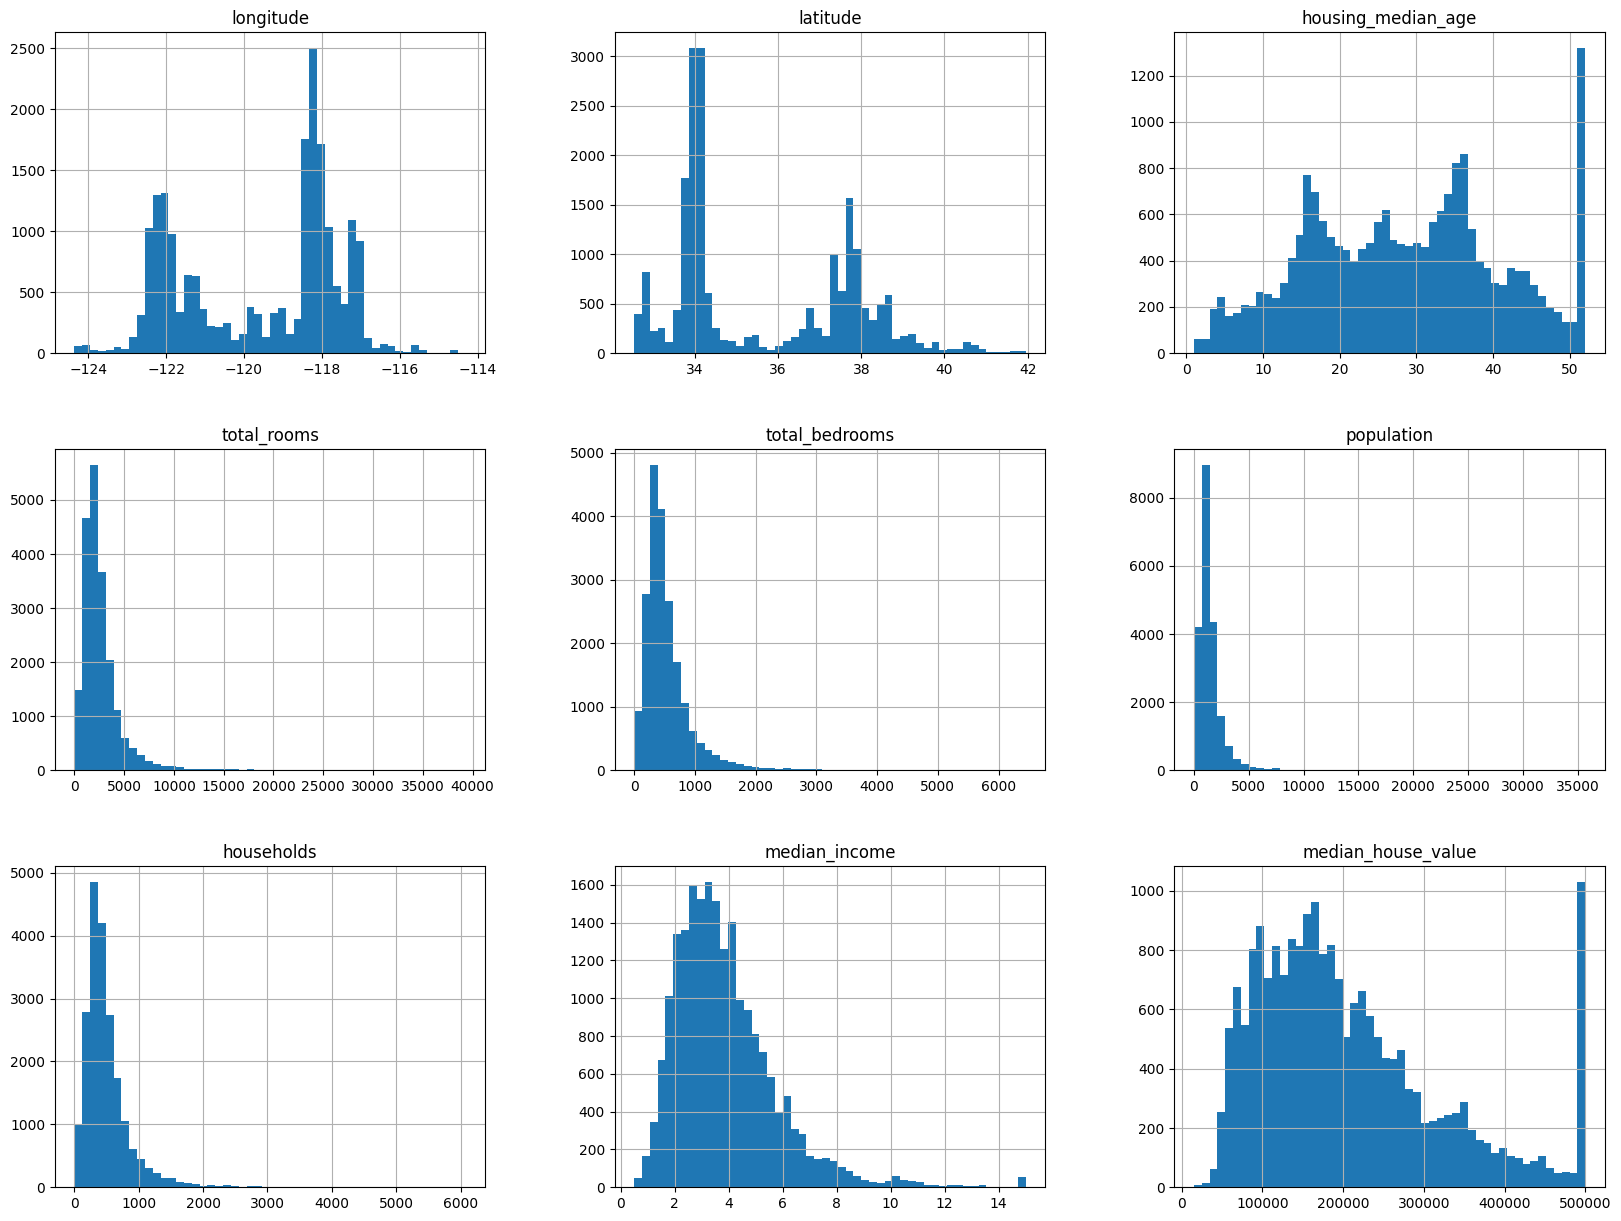

In [14]:
%matplotlib inline
housing.hist(bins=50 , figsize=(20,15))
plt.show()

Bu  datasetde test set  deyisir . her defe tesadufi  ededler geldiyi ucun

In [15]:
def split_train_test(data , test_ratio):
    shuffled_indices =  np.random.permutation(len(data))
    print(shuffled_indices)
    test_set_size    =  int(len(data) *  test_ratio)
    print(test_set_size)

    test_indices     =  shuffled_indices[:test_set_size]
    print(test_indices)
    train_indices    =  shuffled_indices[test_set_size:]
    print(train_indices)

    return  data.iloc[train_indices] , data.iloc[test_indices]

In [16]:
train_set, test_set  = split_train_test(housing , 0.2)
print(len(train_set), 'train +' ,  len(test_set), 'test')

[ 3425 11108 12320 ... 13675 12019  3390]
4128
[ 3425 11108 12320 ... 11300  7822 16929]
[ 7029 14775   348 ... 13675 12019  3390]
16512 train + 4128 test


Ikinci  method hash  funskiyasi isttifade etmekle  mumkundur 


Çalışma Örneği:
Diyelim ki:

ID = 42

test_ratio = 0.2

hash = hashlib.md5

Adımlar:

np.int64(42) → 42 (integer'a çevir)

hashlib.md5(np.int64(42)) → Hash değeri hesapla

.digest()[-1] → Hash'in son byte'ını al (örneğin: 37)

37 < 256 * 0.2 → 37 < 51.2 → True

ID=42 olan satır test setine gider

In [17]:
import  hashlib

def test_set_check (identifier , test_ratio , hash):
    
    return  hash(np.int64(identifier)).digest()[-1] <  256 *  test_ratio


def split_train_test_by_id (data ,  test_ratio, id_column ,  hash=hashlib.md5):
    ids         = data[id_column]   # index sutunu 
    in_test_set = ids.apply(lambda id_ : test_set_check(id_, test_ratio, hash))

    return data.loc[~in_test_set], data.loc[in_test_set]

In [18]:
housing_with_id       = housing.reset_index()   # index sutunu  elave etdi
test_set , train_set = split_train_test_by_id(housing_with_id, 0.2 ,'index')

Burada coğrafi koordinatları (enlem ve boylam) kullanarak benzersiz bir ID oluşturuyorlar. 

Problem:
Satır indeksi (index) kullanmak riskli, çünkü:

Veri silinebilir → ID'ler kaybolur

Veri sırası değişebilir

Yeni veri her zaman sona eklenmeyebilir

Çözüm:
Verinin doğasında bulunan stabil özelliklerini kullanarak ID oluştur:

In [19]:
housing_with_id['id'] = housing['longitude'] * 1000 + housing['latitude']
print(housing_with_id['id'])
train_set, test_set = split_train_test_by_id(housing_with_id , 0.2 ,'id')


0       -122192.12
1       -122182.14
2       -122202.15
3       -122212.15
4       -122212.15
           ...    
20635   -121050.52
20636   -121170.51
20637   -121180.57
20638   -121280.57
20639   -121200.63
Name: id, Length: 20640, dtype: float64


In [20]:
# Sckit_learn  -le train  test  split
from  sklearn.model_selection import  train_test_split
train_set ,  test_set =  train_test_split(housing,test_size=0.2 , random_state =42)

Medyan gelir, konut fiyatını tahmin etmede çok önemli bir özellik. Eğer test setimiz, tüm veri setindeki gelir dağılımını temsil etmezse:

Model yanlılığı (bias) oluşur

Düşük gelirli evler için iyi, yüksek gelirli evler için kötü performans gösterebilir

Gerçek dünya performansı yanıltıcı olur

Çözüm: Stratified Sampling
Test setinin, tüm veri setindeki gelir kategorilerinin oranını korumasını sağlamak

In [21]:
housing['income_cat'] = np.ceil(housing['median_income'] /  1.5)
housing['income_cat'] .where(housing['income_cat'] < 5 , 5.0 ,inplace=True)
housing['income_cat']

C:\Users\USER\AppData\Local\Temp\ipykernel_18600\1708697305.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing['income_cat'] .where(housing['income_cat'] < 5 , 5.0 ,inplace=True)


0        5.0
1        5.0
2        5.0
3        4.0
4        3.0
        ... 
20635    2.0
20636    2.0
20637    2.0
20638    2.0
20639    2.0
Name: income_cat, Length: 20640, dtype: float64

In [22]:
from  sklearn.model_selection import StratifiedShuffleSplit

In [23]:
split = StratifiedShuffleSplit( n_splits= 1,
                               test_size=0.2,
                               random_state=42)
for train_index,test_index in  split.split(housing,housing['income_cat']):
    strat_train_set = housing.loc[train_index]
    strat_test_set  = housing.loc[test_index]
    
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND,2.0
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN,5.0
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND,2.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN,2.0
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN,3.0
...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN,4.0
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND,2.0
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN,3.0
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN,3.0


In [24]:
strat_test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN,5.0
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN,4.0
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN,3.0
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN,3.0
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN,3.0
...,...,...,...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170,110000.0,<1H OCEAN,2.0
7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615,118800.0,<1H OCEAN,2.0
17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000,293800.0,<1H OCEAN,4.0
10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125,335700.0,<1H OCEAN,4.0


In [25]:
strat_test_set['income_cat'].value_counts() / len(strat_test_set)

income_cat
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: count, dtype: float64

In [26]:
for set_  in (strat_train_set,strat_test_set):
    set_.drop('income_cat',axis =1 ,inplace=True)

Bu hissə deyir ki, artıq məlumatı daha dərindən araşdırmağın vaxtıdır. İndiyə qədər yalnız ümumi baxış etmişdik, indi isə məqsəd datanın içindən real anlayışlar çıxarmaqdır.

Bu mərhələdə sən test setə toxunmadan, yalnız training setin bir kopyası üzərində işləyərək datanı dərindən analiz etməyə başlayırsan ki, model üçün faydalı məlumatlar əldə edəsən

In [27]:
housing = strat_train_set.copy()

Bu mərhələdə sən xəritə üzərində baxaraq başa düşürsən ki, ev qiymətləri əsasən harada yaşadıqlarına bağlıdır, və bu məlumatı sonradan modeldə ağıllı şəkildə istifadə etmək olar.

<Axes: xlabel='longitude', ylabel='latitude'>

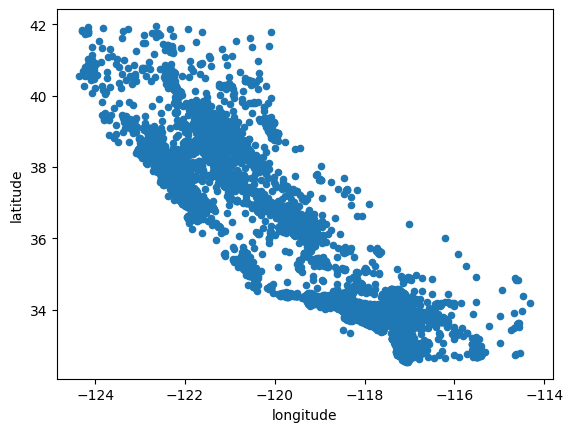

In [28]:
housing.plot(kind='scatter',x='longitude',y='latitude')

<Axes: xlabel='longitude', ylabel='latitude'>

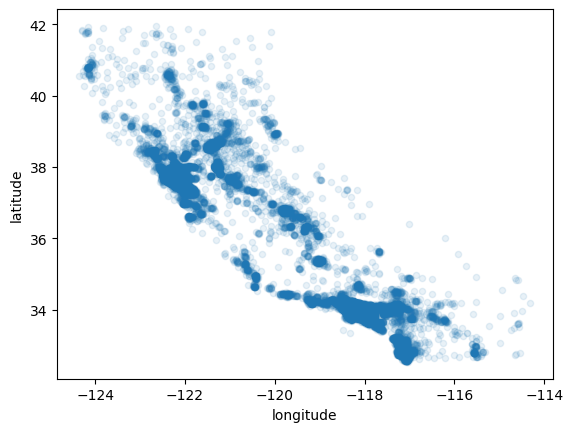

In [29]:
housing.plot(kind='scatter',x='longitude',y='latitude',alpha=0.1)

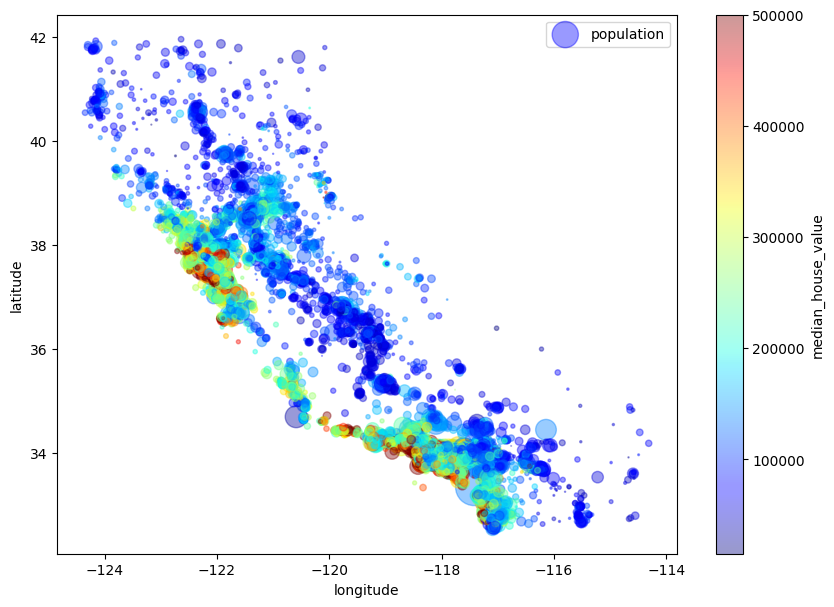

In [30]:
housing.plot(kind='scatter',
             x='longitude',
             y='latitude',
             alpha=0.4,
             s=housing['population']/50,
             label='population',
             figsize=(10,7),
             c='median_house_value',
             cmap=plt.get_cmap('jet'),
             colorbar=True,)
plt.legend()

In [31]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN


In [32]:
corr_matrix = housing.select_dtypes(include=[np.number]).corr()



In [33]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

Korrelyasiya yalnız xətti əlaqəni tutur.
Məsələn:

“x artdıqca y artır” → görünür

Amma “x sıfıra yaxın olanda y artır” → görünməyə bilər

Yəni:

Korrelyasiya 0 olsa belə, arada əlaqə ola bilər – sadəcə düz xətt formasında deyil.

# -----------------

Scatter plot və scatter matrix nə üçün lazımdır?

Sən:

Sadəcə rəqəmlərə baxmırsan

Qrafiklə görürsən

scatter_matrix:

Bir neçə dəyişəni bir-biri ilə müqayisə edir.

Hansının hansıyla daha yaxşı uyğun gəldiyini gözlə görürsən

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

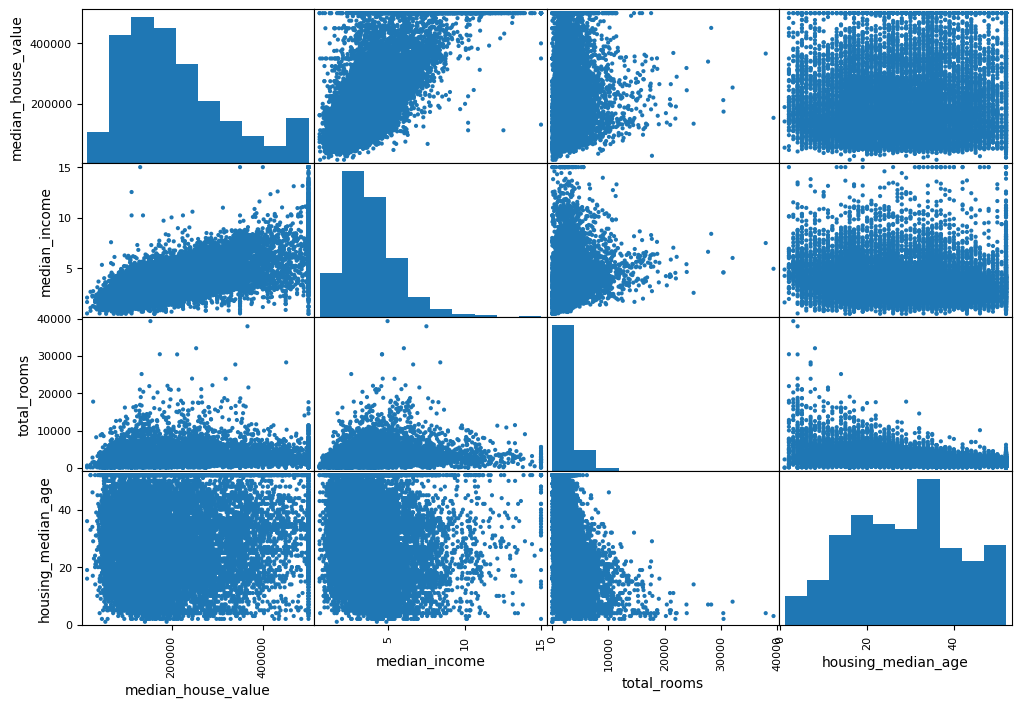

In [34]:
from  pandas.plotting import  scatter_matrix

attributes =['median_house_value',
             'median_income',
             'total_rooms',
             'housing_median_age']
scatter_matrix(housing[attributes],figsize=(12,8),alpha=1)

<Axes: xlabel='median_income', ylabel='median_house_value'>

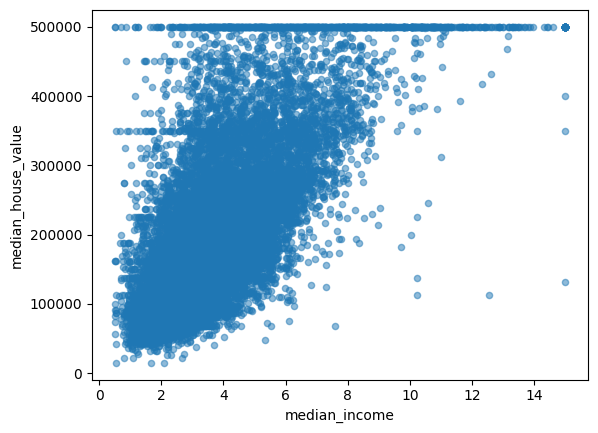

In [35]:
housing.plot(kind='scatter',
             x='median_income',
             y='median_house_value',
             alpha=0.5,
             )

# Buradan çıxan nəticələr:

* Güclü trend var*

Gəlir ↑ → Ev qiyməti ↑

* $500,000 tavanı açıq görünür *

Qiymətlər orada “kəsilib”

Bu model üçün problem yarada bilər

* Qəribə düz xətlər var*


  $450k, $350k, $280k ətrafında sanki süni xətlər


  Bunlar datanın qüsuru ola bilər


  Model bunları öyrənib səhv qayda çıxara bilər


  Ona görə:
    Bu nöqtələri silmək barədə düşünmək olar.

------------------------------------------

Bu hissədə sən mövcud sütunlardan daha mənalı yeni xüsusiyyətlər (features) yaratmağın nə qədər vacib olduğunu öyrənirsən.

## Burada əsas fikir nədir?

Bəzi sütunlar təkbaşına çox şey demir, amma bir-biri ilə birləşdiriləndə model üçün çox daha faydalı olur.

Məsələn:

* total_rooms təkbaşına → çox şey demir

Amma:

* rooms per household → evlərin nə qədər böyük olduğunu göstərir

* bu isə qiymət üçün çox vacibdir

In [36]:
housing['rooms_per_household']      = housing['total_rooms']     / housing['households']
housing['bedrooms_per_room']        = housing['total_bedrooms'] / housing['total_rooms']
housing['population_per_household'] = housing['population']    / housing['households']

In [37]:
corr_matrix = housing.select_dtypes(include=[np.number]).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

Sonra nə etdik?

Yenidən korrelyasiyaya baxdıq və gördük ki:

*   bedrooms_per_room
    * → ev qiyməti ilə daha güclü əlaqəlidir

* rooms_per_household
   
    * → total_rooms-dan daha informativdir

Yəni:

Yeni yaratdığımız sütunlar köhnələrdən daha ağıllıdır.

In [38]:
housing        = strat_train_set.drop('median_house_value',axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

1. Predictor və label ayrılır

* housing → giriş dəyişənləri (features)

* housing_labels → çıxış dəyişəni (target)

Bu çox vacibdir, çünki:

* Feature-lara tətbiq etdiyin transformasiyalar label-a tətbiq olunmamalıdır.

Məsələn:

* Standartlaşdırma, doldurma, encoding → yalnız X üçün

* Y üçün isə tamam başqa strategiya ola bilər.

## Data Cleaning


# Missing value üçün 3 strategiya

Sənin qarşısında üç fundamental seçim var:

* Sətirləri silmək  -  Risklidir: məlumat itkisi yaradır.
* Sütunu silmək     - Risklidir: informativ feature itirə bilərsən.
* Dəyər ilə doldurmaq (imputation) -  en profisional yanasma 



In [39]:
# housing.dropna(subset=['total_bedrooms'],axis=0)
# housing.drop('total_bedrooms',axis=1)

In [40]:
median  =  housing['total_bedrooms'].median()
housing['total_bedrooms'].fillna(median, inplace =True)

C:\Users\USER\AppData\Local\Temp\ipykernel_18600\1509267299.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing['total_bedrooms'].fillna(median, inplace =True)


Imputation yalnız train set üzərində öyrənilməlidir.
Sonra:

* test set

* real sistemə gələn yeni data
hamısı eyni median ilə doldurulmalıdır.

Əks halda:

* Data leakage yaranır və modelin qiymətləndirilməsi saxta şəkildə yaxşı görünür.

In [41]:
from  sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
imputer

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


Əl ilə fillna() etmək olar, amma sistem qurmaq üçün yetərli deyil.
Buna görə Imputer (indiki adı SimpleImputer) istifadə olunur

Bu artıq:

* avtomatlaşdırıla bilən

* pipeline-a daxil edilə bilən

* production-ready
bir həll deməkdir.

In [42]:

housing_num = housing.drop('ocean_proximity', axis =1)

Çünki:

* Median yalnız rəqəmsal sütunlarda hesablana bilər.

* ocean_proximity isə kategorik dəyişəndir (string).

In [43]:
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


Bu əməliyyat:

* Hər sütunun medianını hesablayır

* Onları imputer.statistics_ içində saxlayır

In [44]:
X = imputer.transform(housing_num)
X

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]], shape=(16512, 8))

Bu addım:

* Bütün missing value-ları

* əvvəl öyrənilmiş medianlarla

* avtomatik əvəz edir

Nəticə:

* artıq tam, təmiz, numeric matrix əldə edirsən.

* modelə verməyə hazır forma

In [45]:
housing_num.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

In [46]:
housing_tr = pd.DataFrame( X , columns = housing_num.columns)
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
1,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
3,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
4,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964
...,...,...,...,...,...,...,...,...
16507,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900
16508,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139
16509,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797
16510,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964


Numpy array işləyir, amma:

  * sütun adları itir

  * analiz çətinləşir

DataFrame isə:

 * oxunaqlıdır

 * debug asandır

 * pipeline inteqrasiyası rahatdır

In [47]:
imputer.strategy

'median'

In [48]:
imputer.statistics_
# Alt xətli (_) dəyişənlər:   “Bu dəyər fit() zamanı öyrənilib.”

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

# ocean_proximity sütunu mətn tipindədir:

Amma:
* Əksər ML alqoritmləri yalnız ədədlərlə işləyir.
Ona görə bu sütunu rəqəmsal formaya salmalıyıq.

In [49]:
housing_cat =  housing['ocean_proximity']
housing_cat.head(10)

12655        INLAND
15502    NEAR OCEAN
2908         INLAND
14053    NEAR OCEAN
20496     <1H OCEAN
1481       NEAR BAY
18125     <1H OCEAN
5830      <1H OCEAN
17989     <1H OCEAN
4861      <1H OCEAN
Name: ocean_proximity, dtype: object

factorize() nə edir?

* Hər fərqli kateqoriyaya bir integer ID verir.

In [50]:
housing_cat.factorize()

(array([0, 1, 0, ..., 2, 2, 0], shape=(16512,)),
 Index(['INLAND', 'NEAR OCEAN', '<1H OCEAN', 'NEAR BAY', 'ISLAND'], dtype='object'))

In [51]:
housing_cat_encoded, housing_categories = housing_cat.factorize()

Əgər biz kateqoriyanı sadəcə 0,1,2 kimi versək:
* Model belə düşünəcək:   2, 0-dan iki dəfə böyükdür → deməli daha “yaxındır”.
* Bu isə tam səhv məntiqdir.Kateqoriyalar arasında rəqəmsal məsafə mənasızdır.

In [52]:
housing_cat_encoded

array([0, 1, 0, ..., 2, 2, 0], shape=(16512,))

In [53]:
housing_categories

Index(['INLAND', 'NEAR OCEAN', '<1H OCEAN', 'NEAR BAY', 'ISLAND'], dtype='object')

#  One-Hot Encoding

Məntiq:
Hər kateqoriya üçün ayrı sütun yaradılır.

In [54]:
from  sklearn.preprocessing import  OneHotEncoder

encoder = OneHotEncoder()
# OneHotEncoder 2D array gözləyir
housing_cat_1hot = encoder.fit_transform(housing_cat_encoded.reshape(-1,1))
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

* Yəni matrisin 99%-i sıfırdır.Bunu normal array kimi saxlamaq yaddaş israfıdır.
* Scipy  Sparse matrix istifadə edir — yalnız 1 olan yerləri saxlayır.

In [55]:
# Əgər mütləq Numpy dense array lazımdırsa:
housing_cat_1hot.toarray()

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.]], shape=(16512, 5))

# Transformers

Bir transformer üçün minimum tələblər:

* fit()

* transform()

* fit_transform()

Əgər sən:

* TransformerMixin----- əlavə etsən → *fit_transform()* avtomatik gəlir

Əgər sən:

* BaseEstimator---- əlavə etsən → *get_params()* , *set_params()*  gəlir → bu da GridSearch, hyperparameter tuning üçün kritikdir.

*add_bedrooms_per_room* --- hyperparameter-dir,yəni model seçimi kimi, sən bunu da optimizasiya edə bilərsən .

In [56]:
housing.values[:,3]   # total_rooms  sutunu
housing.values[:,6]    # households sutunu
# ve.s

array([706.0, 768.0, 300.0, ..., 172.0, 501.0, 197.0],
      shape=(16512,), dtype=object)

In [57]:
from  sklearn.base import  BaseEstimator,TransformerMixin 
rooms_ix, bedroom_ix,population_ix,household_ix = 3 ,4, 5, 6

class CombinedAttributesAdder(BaseEstimator,TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    
    def fit(self, X , y=None):
        return  self
    
    def transform(self, X , y=None):
        # otaq sayi  /  ev_sayi
        rooms_per_household      = X[:,rooms_ix]       / X[:,household_ix]
        # ehali sayi / ev_sayi
        population_per_household = X[:,population_ix] / X[:,household_ix]
        
        if self.add_bedrooms_per_room:   # False olsa islemeyecek 
            # yataq otagi / umumi  otaq sayi
            bedrooms_per_room = X[:, bedroom_ix] / X[:, rooms_ix]
            #  sutunlari birlesdirir column stack
            return np.c_[ X,
                         rooms_per_household,
                         population_per_household,
                         bedrooms_per_room ]
        else :
            return np.c_[ X,
                          rooms_per_household,
                          population_per_household ]
        
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)
        

# Feature Scaling


## Problem nədir?

Dataset-də atributların **ölçüləri çox fərqlidir**:

* `total_rooms`: 6 → 39,000
* `median_income`: 0 → 15

Əksər Machine Learning alqoritmləri bu halda:
> böyük rəqəmli feature-lərə **daha çox əhəmiyyət** verir,
> nəticədə model **qərəzli** öyrənir.
Ona görə:**Input feature-lər eyni miqyasda olmalıdır.**
(Qeyd: target — yəni `median_house_value` — adətən scale edilmir.)
---
## İki əsas üsul var

### 1. Min–Max Scaling (Normalization)
Formul:  *x -  min  /  max - min*

Nəticə:
* bütün dəyərlər → **0 ilə 1 arasında**
* Üstünlük: **sadə və intuitivdir**
* Çatışmazlıq: **outlier**-lərə çox həssasdır.

### 2. Standardization	​
*x-mean(x) / std*

Nəticə: 
* orta = 0
* dispersiya = 1

Üstünlük:  outlier-lərdən **az təsirlənir**
Çatışmazlıq: nəticə müəyyən intervalda olmur (−∞, +∞)
## Hansını nə vaxt seçməli?
| Vəziyyət                               | Tövsiyə            |
| -------------------------------------- | ------------------ |
| Outlier çoxdur                         | **StandardScaler** |
| Neural Network, [0–1] aralığı lazımdır | **MinMaxScaler**   |
| Ümumi default seçim                    | **StandardScaler** |




1. Feature scaling **məcburidir**, istəyə bağlı deyil.
2. İki əsas üsul var:

   * MinMaxScaler
   * StandardScaler
3. Outlier varsa → StandardScaler üstünlükdür.
4. Scaler yalnız **training data** üzərində fit edilir.
5. Eyni scaler:
   * train
   * test
   * production data     üçün istifadə olunur.

# Transformation Pipelines


Pipeline bunun həllidir: preprocessing-i deterministik alqoritmə çevirir.

Sənin preprocessing mərhələlərin artıq çoxdur:

* feature engineering

* scaling

* categorical encoding

* s.

Bunları əl ilə ardıcıl icra etsən:


* Imputer → boş dəyərləri medianla doldurur

* CombinedAttributesAdder → yeni feature-lər yaradır

* StandardScaler → bütün numeric-ləri scale edir

* fit_transform() bütün addımları ardıcıl icra edir

* output → artıq model üçün hazır matrisdir

In [58]:
from  sklearn.pipeline import  Pipeline
from  sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer',       SimpleImputer(strategy = 'median') ),
    ('attribs_adder', CombinedAttributesAdder() ),
    ('std_scaler',     StandardScaler() ),
])

housing_num_tr = num_pipeline.fit_transform(housing_num)

Səndə var:

* numeric columns

* categorical columns (ocean_proximity)

Pipeline isə:

* NumPy array gözləyir

* DataFrame ilə birbaşa işləmək istəmir

Həll: DataFrameSelector

Bu transformer:
* lazımi sütunları seçir  ve  DataFrame → NumPy array çevirir

In [59]:
from  sklearn.base import  BaseEstimator ,TransformerMixin

class DataFrameSelector(BaseEstimator ,TransformerMixin):

    def __init__(self, attribute_names):
        self.attribute_names =  attribute_names

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return  X[self.attribute_names].values 

In [60]:
# a) Numeric pipeline
num_attribs = list(housing_num)  #  sutun adlari

num_pipeline = Pipeline([
    ('selector',      DataFrameSelector(num_attribs)),
    ('imputer',       SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler',    StandardScaler()),
])



# b) Categorical pipeline   
cat_attribs =['ocean_proximity']  #  sutun adlari

cat_pipeline = Pipeline([
    ('selector',       DataFrameSelector(cat_attribs)),
    ('onehot_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])


In [61]:
# 6. Birləşdirmə: FeatureUnion

from  sklearn.pipeline  import  FeatureUnion

full_pipeline = FeatureUnion(transformer_list=[
    ('num_pipeline' ,num_pipeline ),
    ('cat_pipeline' ,cat_pipeline ),
])

housing_prepared = full_pipeline.fit_transform(housing)

FeatureUnion nə edir?

* Numeric pipeline-i işlədir

* Categorical pipeline-i paralel işlədir

* Nəticələri yan-yana birləşdirir

* Modelə veriləcək final matrisi yaradır

In [62]:
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]], shape=(16512, 16))

In [63]:
housing_prepared.shape

(16512, 16)

# Select and Train a Model


## Training and Evaluating on the Training Set


İndiyə qədər sən:

* Problemi formalaşdırdın

* Data-nı topladın

* Train/Test ayırdın

* Preprocessing pipeline yazdın

İndi isə:

 * model seçimi və ilkin qiymətləndirmə mərhələsindəsən.

* Bu mərhələnin məqsədi:

* “Bu data ilə hansı model ailəsi işləyir?”
* “Sadə model kifayətdirmi, yoxsa kompleks lazımdır?”

# Linear Regression 

In [64]:
from sklearn.linear_model import LinearRegression

lin_reg =LinearRegression()
lin_reg.fit(housing_prepared,housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
some_data   = housing.iloc[:5]   # X
some_labels = housing_labels.iloc[:5] # y

print(some_data)
print(some_labels,'\n')

some_data_prepared = full_pipeline.transform(some_data)

print('Predictors: ', lin_reg.predict(some_data_prepared) ,'\n')
print('Lables : '   , list(some_labels) )

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12655    -121.46     38.52                29.0       3873.0           797.0   
15502    -117.23     33.09                 7.0       5320.0           855.0   
2908     -119.04     35.37                44.0       1618.0           310.0   
14053    -117.13     32.75                24.0       1877.0           519.0   
20496    -118.70     34.28                27.0       3536.0           646.0   

       population  households  median_income ocean_proximity  
12655      2237.0       706.0         2.1736          INLAND  
15502      2015.0       768.0         6.3373      NEAR OCEAN  
2908        667.0       300.0         2.8750          INLAND  
14053       898.0       483.0         2.2264      NEAR OCEAN  
20496      1837.0       580.0         4.4964       <1H OCEAN  
12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
Name: median_house_value, dtype: float64 

Predictors:  [

## MSE fro linear model

In [66]:
from  sklearn.metrics import mean_squared_error
housing_predictions =  lin_reg.predict(housing_prepared)

lin_mse = mean_squared_error(housing_labels ,  housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

Bu  model  underfitting olduguna gore (68,627 $ error verir) biz indi  ya yeni  model secmeliyik , ya yeni feature ler elave etmeliyik , yada constarinleri azalatmaliyiq . 

# DecisionTreeRegressor

In [67]:
from  sklearn.tree import  DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared,housing_labels)
housing_predictions = tree_reg.predict(housing_prepared)

# MSE for  Tree

In [68]:
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse 

np.float64(0.0)

# Random Forest

In [69]:
from  sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared , housing_labels)
housing_predictions_rd = forest_reg.predict(housing_prepared)

# MSE for Forest

In [70]:
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(0.0)

# Better Evaluation Using Cross-Validation

Tək bir validation split:

* təsadüfi ola bilər

* optimistik və ya pessimist nəticə verə bilər

* modelin stabilliyini göstərmir

K-fold cross-validation isə:

* modelin performansını paylanma kimi ölçür, tək ədəd kimi yox.

In [71]:
from  sklearn.model_selection import  cross_val_score


In [72]:
scores =  cross_val_score( tree_reg,
                           housing_prepared,
                           housing_labels,
                           scoring='neg_mean_squared_error',
                           cv = 10)
tree_rmse_scores = np.sqrt(- scores)


def display_scores (scores):
    print('Scores :' , np.round(scores))
    print('Mean :', scores.mean())
    print('Standart deviation :' , scores.std())

display_scores(tree_rmse_scores)   #  tree  ucun  rmse

Scores : [72990. 71809. 67638. 70706. 70327. 78442. 71861. 73977. 67363. 70043.]
Mean : 71515.5418959241
Standart deviation : 3048.4544906428337


In [73]:
lin_scores =  cross_val_score(lin_reg,
                              housing_prepared,
                              housing_labels,
                              scoring='neg_mean_squared_error',
                              cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)

display_scores(lin_rmse_scores)    # linear model ucun  rmse 

Scores : [71763. 64115. 67771. 68635. 66846. 72528. 73997. 68802. 66443. 70140.]
Mean : 69104.07998247063
Standart deviation : 2880.3282098180584


In [74]:
forest_rmse =  cross_val_score( forest_reg,
                              housing_prepared,
                              housing_labels,
                              scoring='neg_mean_squared_error',
                              cv=10 )

forest_rmse_scores = np.sqrt(- forest_rmse)

display_scores(forest_rmse_scores) 


Scores : [51511. 49192. 46795. 52175. 47593. 51604. 52270. 49873. 48437. 54014.]
Mean : 50346.402193866976
Standart deviation : 2209.6622915710327


Burada üç konkret həll yolu deyilir:
1) Modeli sadələşdirmək

Random Forest-də bu:

* daha az tree

* daha az dərinlik (max_depth)

2) Modeli məhdudlaşdırmaq (regularization)

Məsələn:

* min_samples_leaf

* max_features

3) Daha çox training data

Çünki:

* çox data → model əzbərləyə bilmir, öyrənməyə məcbur qalır

Yəni müəllif deyir:

      Overfitting texniki problemdir və texniki həlləri var.

Muxtelif modelleri  sina svm, neural network  ,  diger ml  alqoritmleri . Sonra onlari derinden isle.
Her sinadigin  model ucun  
* Hyperparametr-ler  _ Random  Forest ucun meselen: n_estimators , max_depth
* Oyrenilmis parametrler _ 
* Cross_validation  neticeler _
* Proqnozlar 

Çünki yalnız belə olduqda sən:

* Modelləri obyektiv müqayisə edə bilirsən
* Hansı model hansı tip səhv edir, görə bilirsən 
*  Sonra geri qayidib " bu verisya yaxsi idi  deye bilersen"




5. “You can easily save models with joblib…”

Bu hissə texniki olaraq nə deyir?

Scikit-Learn modellərini:  
* joblib.dump(my_model, "my_model.pkl")    ilə fayla yazırsan.

Sonra istədiyin vaxt:
*  my_model_loaded = joblib.load("my_model.pkl")  ilə eyni modeli geri yükləyirsən.

Bu o deməkdir ki: Yenidən training etməyə ehtiyac yoxdur

Eyni model: 

* test üçün

* müqayisə üçün

* deployment üçün  istifadə oluna bilər.

# Fine-Tune Your Model


Bu mərhələdə artıq:

* bir neçə yaxşı model seçmisən

* indi məqsəd:
bu modellərin parametrlərini optimallaşdırmaqdır.

Modelin içində olan bu parametrlərə hyperparameter deyilir

## Grid Search


El ile bir parametr deyise,  modeli  yeniden train ede sonra neticeye baxa bilersen .

Amma gridsearch  senin evezine butun  kombinasiyalari  yoxlayir,  cross_validation  ile her kombinasiyani  olcur ve en yaxsisini  secir .

Estimator sayi  kimi  ilk  basda 10-nun  quvvetlerin  vere bilersiz. Bu size hansi  araliqda yaxsi performans verildiyini  aydin edir ve sonra siz *ince axtaris* edirsiz . Veya daha deqiq axtaris isteyirsizse six araliqda ededler goturun.

In [75]:
from  sklearn.model_selection import  GridSearchCV

param_grid  = [
    {'n_estimators': [3,10,30], 'max_features': [2,4,6,8] },   # 12 kombinasiya, bootstrap = True olur default ona gore yazmadiq
    {'bootstrap':    [False]  , 'n_estimators': [3,10], 'max_features': [2,3,4] }  # 6 kombinasiya 
]
#  12 + 6 = 18  * (cv = 5)  = 90
forest_reg =RandomForestRegressor()
grid_search = GridSearchCV(forest_reg,
                           param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error')
grid_search.fit(housing_prepared,  housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [76]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [77]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [83]:
grid_search.best_score_

np.float64(-2495318888.6138496)

In [84]:
grid_search.best_index_

np.int64(8)

* GridSearchCV ən yaxşı parametrləri tapandan sonra,
əgər refit=True-dirsə,
həmin modeli bütün training datası ilə yenidən öyrədir —
çünki daha çox data ilə öyrədilən model adətən daha yaxşı performans göstərir.

In [78]:
grid_search.cv_results_

{'mean_fit_time': array([0.08161244, 0.25498681, 0.75571957, 0.12197022, 0.401015  ,
        1.24294319, 0.17217178, 0.57662411, 1.73322186, 0.23803444,
        0.72897406, 2.20958738, 0.12308593, 0.40413709, 0.15981336,
        0.53447995, 0.20365281, 0.66623163]),
 'std_fit_time': array([0.00175664, 0.01141055, 0.01519919, 0.00155997, 0.00620147,
        0.0241523 , 0.004123  , 0.00255876, 0.013258  , 0.03008322,
        0.00546982, 0.00934345, 0.00259936, 0.00689588, 0.00454982,
        0.00162354, 0.00296365, 0.00927882]),
 'mean_score_time': array([0.00434437, 0.01181016, 0.03474712, 0.00430188, 0.01188297,
        0.03585119, 0.0045639 , 0.01291251, 0.03647351, 0.00429826,
        0.0130393 , 0.03626814, 0.00543003, 0.01497431, 0.005373  ,
        0.01484785, 0.00525203, 0.01357632]),
 'std_score_time': array([0.00034215, 0.0006172 , 0.00255241, 0.00016027, 0.00088991,
        0.00113607, 0.00048853, 0.00088   , 0.0017919 , 0.00026201,
        0.00045178, 0.00162882, 0.00053989, 

In [86]:
cvres =  grid_search.cv_results_
zip(cvres['mean_test_score'], cvres['params'])

In [88]:
cvres =  grid_search.cv_results_

for  mean_score, params in zip(cvres['mean_test_score'], cvres['params']):
    print(round(np.sqrt(-mean_score)),'ve ', params)

63845 ve  {'max_features': 2, 'n_estimators': 3}
54765 ve  {'max_features': 2, 'n_estimators': 10}
52698 ve  {'max_features': 2, 'n_estimators': 30}
60847 ve  {'max_features': 4, 'n_estimators': 3}
52941 ve  {'max_features': 4, 'n_estimators': 10}
50879 ve  {'max_features': 4, 'n_estimators': 30}
58683 ve  {'max_features': 6, 'n_estimators': 3}
52143 ve  {'max_features': 6, 'n_estimators': 10}
49953 ve  {'max_features': 6, 'n_estimators': 30}
58309 ve  {'max_features': 8, 'n_estimators': 3}
52692 ve  {'max_features': 8, 'n_estimators': 10}
50307 ve  {'max_features': 8, 'n_estimators': 30}
62290 ve  {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
53878 ve  {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60428 ve  {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52313 ve  {'bootstrap': False, 'max_features': 3, 'n_estimators': 10}
59442 ve  {'bootstrap': False, 'max_features': 4, 'n_estimators': 3}
51973 ve  {'bootstrap': False, 'max_features': 4, 'n_esti

* Fine-tuning işləyir.
Düzgün hyperparameter seçimi real olaraq səhvi azaldır.

* Optimizasiya təkcə modeldə bitmir.
Data hazırlama mərhələsi də eyni dərəcədə kritikdir.

* Ən peşəkar yanaşma:
modeli, feature engineering-i, preprocessing qərarlarını hamısını vahid optimizasiya problemi kimi görməkdir.

# Randomized Search


Randomized search Vs Grid Search

* 1 ci ferqi estimator sayina uniform(10,1000) deyirsense her iterasiyada gedib tesadufi  bir deyer gotuurr onda eger 100 iterasiya olsa 1000 ferqli deyer goturur. Amma grid-de n_estimator=[10,20,30] kimi verilir.


* 2 ci  ferqi  is yuku azalir ,yeni  iterasiya sayi * (cv=k) olur amma bu  Grid -de kombinasiya sayi * (cv=k) olur. iterasiya sayin ozun secirsen

Qisaca kicik  probleme Grid , Boyuk ,murekkeb probleme Randomized search secile biler .

# Ensemble Methods 

# Analyze the Best Models and Their Errors

* Modelin nece dusunduyunu  anlamq ucun  modelin  *feature importance* - istifade olunur.
* Eger neticeler 0 -a yaxin olarsa  atrubutun  proqnoza tesiri  cox az olur  ,  eksine boyuk reqem olarsa model ucun  bu  atribut cox vacibdir.


In [94]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([8.16073393e-02, 6.74758354e-02, 4.08796097e-02, 1.77672632e-02,
       1.63341761e-02, 1.77349465e-02, 1.63130781e-02, 3.04590216e-01,
       6.78409175e-02, 1.07938225e-01, 8.20737650e-02, 1.42174039e-02,
       1.55388423e-01, 2.94049153e-05, 5.36779079e-03, 4.44160475e-03])

In [92]:
extra_attribs = ['rooms_per_hhold', 'pop_per_hhold','bedrooms_per_room']
cat_encoder = cat_pipeline.named_steps["onehot_encoder"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
print(num_attribs ,'ve\n', extra_attribs , 've\n',cat_one_hot_attribs)

attributes = num_attribs + extra_attribs + cat_one_hot_attribs

sorted(zip(np.round(feature_importances,3), attributes) , reverse = True)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income'] ve
 ['rooms_per_hhold', 'pop_per_hhold', 'bedrooms_per_room'] ve
 ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']


[(np.float64(0.305), 'median_income'),
 (np.float64(0.155), 'INLAND'),
 (np.float64(0.108), 'pop_per_hhold'),
 (np.float64(0.082), 'longitude'),
 (np.float64(0.082), 'bedrooms_per_room'),
 (np.float64(0.068), 'rooms_per_hhold'),
 (np.float64(0.067), 'latitude'),
 (np.float64(0.041), 'housing_median_age'),
 (np.float64(0.018), 'total_rooms'),
 (np.float64(0.018), 'population'),
 (np.float64(0.016), 'total_bedrooms'),
 (np.float64(0.016), 'households'),
 (np.float64(0.014), '<1H OCEAN'),
 (np.float64(0.005), 'NEAR BAY'),
 (np.float64(0.004), 'NEAR OCEAN'),
 (np.float64(0.0), 'ISLAND')]

* Bezi  feature-ler faydasizdir  , yalniz 1 kateqoriya  real tesir gosterir neticeye 
* Digerlerini  sile bilersen 

# Evaluate Your System on the Test Set


In [ ]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# sadece transform fit-siz, cunki artiq train data uzerinde edilib
X_test_prepared = full_pipeline.transform(X_test)
# model  test set ucun  proqnoz verir
final_predictions = final_model.predict(X_test_prepared)
# real  deyerlerle muqayise olunur
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)   
np.round(final_rmse)

np.float64(47715.0)

Test performansi  asagi ola biler 
1) model  cox tuning edilibse , model validation  data-ni  oyernmis ola biler.


1) Ev qiymetlerini  proqnozlasmada en guclu  faktor  *median  income* oldu.

# Launch, Monitor, and Maintain Your System


1)  sistem performansini  izlemek  ucun  __monitorinq__ kodu  yazmalisan,cunki  model zamanla *drift* olur  ve muntezem olaraq yeni  verilenler oyretmelisen. 

2)  Sistem proqnozlarinin  qiymetlendirilmesi - proqnozlari  numunelerle yoxlamaq ve qiymetlendirme heyata kecirmek

3) Giris melumatlarin monitorinqi sistemi  evvelceden xebardar etmeye komek edir .

4) Model muntezem yeni verilenlerle oyredilmelidir . 
Qeyd : Eger sistemin  online learning tipidirse snapshotlarini  muntezem  saxlayir , isteyende geri qayitmaq rahat olur.

Gördüyün kimi, işin böyük hissəsi:

Məlumat hazırlığı

Monitorinq alətləri qurmaq

İnsan qiymətləndirmə boru xətlərini (pipelines) yaratmaq

Müntəzəm model öyrətməsini avtomatlaşdırmaq
üzerinədir.